In [5]:
!pip install -q \
    langchain \
    langchain-openai \
    langchain-community \
    langgraph \
    tavily-python \
    gradio \
    requests \
    python-dotenv

In [6]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"]       = userdata.get("openai_key")
os.environ["TAVILY_API_KEY"]       = userdata.get("tavily")
os.environ["OPENWEATHER_API_KEY"]  = userdata.get("waether")
os.environ["EXCHANGERATE_API_KEY"] = userdata.get("exchange_rate")



In [7]:
import requests
import json
from langchain_core.tools import tool
from tavily import TavilyClient

@tool
def get_weather(city: str) -> str:
    """
    Get current weather information for a given city.
    Use this when the user asks about weather, temperature, or climate
    in a travel destination.

    Args:
        city: Name of the city (e.g., 'Paris', 'Tokyo', 'New York')
    """
    api_key = os.environ.get("OPENWEATHER_API_KEY", "")
    if not api_key or api_key == "your_key_here":
        return "Weather API key not configured. Please add OPENWEATHER_API_KEY."

    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {"q": city, "appid": api_key, "units": "metric"}

    try:
        resp = requests.get(url, params=params, timeout=10)
        data = resp.json()

        if resp.status_code != 200:
            return f"Could not fetch weather for '{city}'. Error: {data.get('message', 'Unknown error')}"

        weather = data["weather"][0]["description"]
        temp    = data["main"]["temp"]
        feels   = data["main"]["feels_like"]
        humidity= data["main"]["humidity"]
        wind    = data["wind"]["speed"]
        country = data["sys"]["country"]

        return (
            f"Weather in {city}, {country}:\n"
            f"  Condition : {weather.capitalize()}\n"
            f"  Temperature: {temp}°C (feels like {feels}°C)\n"
            f"  Humidity   : {humidity}%\n"
            f"  Wind Speed : {wind} m/s"
        )
    except Exception as e:
        return f"Weather tool error: {str(e)}"


@tool
def get_exchange_rate(from_currency: str, to_currency: str, amount: float = 1.0) -> str:
    """
    Get real-time currency exchange rates and convert amounts.
    Use this when the user asks about currency conversion, exchange rates,
    or how much money they need in a foreign country.

    Args:
        from_currency: Source currency code (e.g., 'USD', 'EUR', 'PKR')
        to_currency  : Target currency code (e.g., 'JPY', 'GBP', 'AED')
        amount       : Amount to convert (default 1.0)
    """
    api_key = os.environ.get("EXCHANGERATE_API_KEY", "")
    if not api_key or api_key == "your_key_here":
        return "Exchange Rate API key not configured. Please add EXCHANGERATE_API_KEY."

    url = f"https://v6.exchangerate-api.com/v6/{api_key}/pair/{from_currency.upper()}/{to_currency.upper()}/{amount}"

    try:
        resp = requests.get(url, timeout=10)
        data = resp.json()

        if data.get("result") != "success":
            return f"Exchange rate error: {data.get('error-type', 'Unknown error')}"

        rate    = data["conversion_rate"]
        result  = data["conversion_result"]

        return (
            f"Currency Exchange:\n"
            f"  {amount} {from_currency.upper()} = {result:.2f} {to_currency.upper()}\n"
            f"  Exchange Rate: 1 {from_currency.upper()} = {rate:.4f} {to_currency.upper()}"
        )
    except Exception as e:
        return f"Exchange rate tool error: {str(e)}"


@tool
def search_travel_info(query: str) -> str:
    """
    Search the web for travel-related information such as attractions,
    visa requirements, best time to visit, travel tips, hotels, and more.
    Use this for general travel knowledge questions.

    Args:
        query: The travel-related search query
    """
    api_key = os.environ.get("TAVILY_API_KEY", "")
    if not api_key or api_key == "tvly-...":
        return "Tavily API key not configured. Please add TAVILY_API_KEY."

    try:
        client  = TavilyClient(api_key=api_key)
        results = client.search(query, max_results=3, search_depth="basic")

        if not results.get("results"):
            return "No search results found."

        formatted = []
        for i, r in enumerate(results["results"], 1):
            formatted.append(f"{i}. {r['title']}\n   {r['content'][:300]}...\n   Source: {r['url']}")

        return "Search Results:\n\n" + "\n\n".join(formatted)
    except Exception as e:
        return f"Search tool error: {str(e)}"


@tool
def calculate_travel_budget(
    destination: str,
    num_days: int,
    hotel_per_night: float,
    food_per_day: float,
    transport_per_day: float,
    activities_total: float = 0.0,
    currency: str = "USD"
) -> str:
    """
    Calculate an estimated travel budget for a trip.
    Use this when the user wants to plan or estimate travel costs.

    Args:
        destination       : Name of travel destination
        num_days          : Number of days of the trip
        hotel_per_night   : Estimated hotel cost per night
        food_per_day      : Estimated food/meals cost per day
        transport_per_day : Estimated local transport cost per day
        activities_total  : Total estimated cost for activities/sightseeing
        currency          : Currency symbol (default 'USD')
    """
    hotel_total     = hotel_per_night * num_days
    food_total      = food_per_day * num_days
    transport_total = transport_per_day * num_days
    subtotal        = hotel_total + food_total + transport_total + activities_total
    emergency_fund  = round(subtotal * 0.10, 2)
    grand_total     = subtotal + emergency_fund

    return (
        f"Travel Budget Estimate for {destination} ({num_days} days)\n"
        f"{'─'*45}\n"
        f"   Hotel         : {hotel_total:.2f} {currency}  ({num_days} nights × {hotel_per_night} {currency})\n"
        f"   Food          : {food_total:.2f} {currency}  ({num_days} days × {food_per_day} {currency})\n"
        f"  Transport     : {transport_total:.2f} {currency}  ({num_days} days × {transport_per_day} {currency})\n"
        f"  Activities    : {activities_total:.2f} {currency}\n"
        f"{'─'*45}\n"
        f"  Subtotal      : {subtotal:.2f} {currency}\n"
        f"  Emergency 10%: {emergency_fund:.2f} {currency}\n"
        f"  GRAND TOTAL   : {grand_total:.2f} {currency}"
    )


tools = [get_weather, get_exchange_rate, search_travel_info, calculate_travel_budget]

print("Tools defined:", [t.name for t in tools])

Tools defined: ['get_weather', 'get_exchange_rate', 'search_travel_info', 'calculate_travel_budget']


In [8]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

class TravelState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.3,
    streaming=False
)
llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = """You are a friendly and knowledgeable AI Travel Assistant.
You help travelers plan trips, check weather, convert currencies, and find
information about destinations around the world.

You have access to these tools:
- get_weather: Check real-time weather for any city
- get_exchange_rate: Convert currencies at live rates
- search_travel_info: Search the web for travel tips, attractions, visa info, etc.
- calculate_travel_budget: Estimate total trip costs

Always be helpful, concise, and proactive — if someone asks about a destination,
offer to check the weather or search for attractions. Format your responses
clearly and include helpful travel tips when relevant."""


def agent_node(state: TravelState) -> TravelState:
    """Main reasoning node — calls the LLM with the current message history."""
    messages = state["messages"]

    if not any(isinstance(m, SystemMessage) for m in messages):
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + messages

    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


def should_use_tools(state: TravelState) -> str:
    """Conditional edge: route to tools if the model made tool calls, else end."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return END


tool_node = ToolNode(tools)

graph_builder = StateGraph(TravelState)

graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)

graph_builder.set_entry_point("agent")

graph_builder.add_conditional_edges(
    "agent",
    should_use_tools,
    {"tools": "tools", END: END}
)

graph_builder.add_edge("tools", "agent")

memory   = MemorySaver()
app      = graph_builder.compile(checkpointer=memory)

print("LangGraph workflow compiled successfully!")
print("\nGraph nodes:", list(app.get_graph().nodes.keys()))

LangGraph workflow compiled successfully!

Graph nodes: ['__start__', 'agent', 'tools', '__end__']


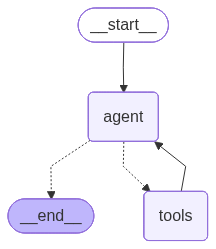

In [9]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization requires additional packages.")
    print("Workflow: User → agent → (tools? → agent) → END")
    print(f"Details: {e}")

In [10]:
def chat(user_input: str, thread_id: str = "test-session") -> str:
    """Send a message to the agent and get a response."""
    config = {"configurable": {"thread_id": thread_id}}
    result = app.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=config
    )
    return result["messages"][-1].content


print("=" * 60)
print("TEST 1: Greeting")
print("=" * 60)
print(chat("Hello! I'm planning a trip to Tokyo. What can you help me with?"))

print("\n" + "=" * 60)
print("TEST 2: Weather Check")
print("=" * 60)
print(chat("What's the weather like in Tokyo right now?"))

print("\n" + "=" * 60)
print("TEST 3: Currency Conversion")
print("=" * 60)
print(chat("How much is 1000 USD in Japanese Yen?"))

print("\n" + "=" * 60)
print("TEST 4: Budget Calculation")
print("=" * 60)
print(chat("Help me estimate a budget for 7 days in Tokyo. Hotel $120/night, food $40/day, transport $15/day, activities total $300."))

TEST 1: Greeting
Hello! I can assist you with various aspects of your trip to Tokyo, including:

1. **Weather**: Check the current weather conditions.
2. **Attractions**: Find popular sights and activities to do in Tokyo.
3. **Travel Budget**: Estimate your trip costs based on your plans.
4. **Currency Exchange**: Provide information on currency conversion rates.
5. **Travel Tips**: Offer advice on transportation, dining, and local customs.

Let me know what specific information you need, and I'll be happy to help!

TEST 2: Weather Check
The current weather in Tokyo is as follows:

- **Condition**: Clear sky
- **Temperature**: 22.7°C (feels like 22.8°C)
- **Humidity**: 69%
- **Wind Speed**: 5.66 m/s

It's a lovely day in Tokyo! If you need any more information or have other questions about your trip, feel free to ask!

TEST 3: Currency Conversion
It seems I'm currently unable to access the live currency exchange rates. However, you can typically find the exchange rate for USD to JPY th

In [11]:
import gradio as gr
import uuid
from langchain_core.messages import HumanMessage

# ── Core chat function for Gradio ────────────────────────────────────────────
def gradio_chat(user_message: str, history: list, session_id: str) -> tuple:
    """
    Gradio chat function.
    - user_message : the new user input
    - history      : list of [user, assistant] pairs (Gradio format)
    - session_id   : unique thread ID for LangGraph memory
    Returns updated history and clears the input box.
    """
    if not user_message.strip():
        return history, ""

    config = {"configurable": {"thread_id": session_id}}

    try:
        result   = app.invoke(
            {"messages": [HumanMessage(content=user_message)]},
            config=config
        )
        response = result["messages"][-1].content
    except Exception as e:
        response = f"❌ Error: {str(e)}\n\nPlease check your API keys are correctly configured."

    history.append([user_message, response])
    return history, ""


def new_session() -> tuple:
    """Reset conversation and generate a new session ID."""
    return [], str(uuid.uuid4())


# ── Example prompts ──────────────────────────────────────────────────────────
EXAMPLES = [
    "What's the weather in Paris right now?",
    "Convert 500 USD to Euros",
    "What are the top attractions to visit in Istanbul?",
    "Estimate my budget for 5 days in Bangkok: hotel $50/night, food $20/day, transport $10/day, activities $150 total",
    "Do I need a visa to visit Japan as a Pakistani citizen?",
    "What's the best time of year to visit Bali?",
    "Convert 10000 PKR to AED",
    "What's the weather in Dubai and what should I pack?",
]

# ── Build the Gradio UI ──────────────────────────────────────────────────────
with gr.Blocks(
    title="✈️ AI Travel Assistant",
    theme=gr.themes.Soft(primary_hue="blue", secondary_hue="sky"),
    css="""
        .header { text-align: center; padding: 20px 0 10px 0; }
        .header h1 { font-size: 2.2em; margin-bottom: 4px; }
        .header p  { color: #555; font-size: 1em; }
        .tool-badge {
            display: inline-block; padding: 2px 10px;
            border-radius: 12px; font-size: 0.8em;
            background: #e8f4fd; color: #1a6fa0;
            margin: 2px; border: 1px solid #b3d9f2;
        }
        footer { display: none !important; }
    """
) as demo:

    # ── Header ──
    gr.HTML("""
        <div class="header">
            <h1>✈️ AI Travel Assistant</h1>
            <p>Powered by LangChain · LangGraph · GPT-4o-mini</p>
            <div style="margin-top:8px">
                <span class="tool-badge">🌤️ Live Weather</span>
                <span class="tool-badge">💱 Currency Exchange</span>
                <span class="tool-badge">🔍 Web Search</span>
                <span class="tool-badge">🧮 Budget Calculator</span>
            </div>
        </div>
    """)

    # ── Hidden session state ──
    session_id = gr.State(value=str(uuid.uuid4()))

    with gr.Row():
        with gr.Column(scale=3):
            # Chat window
            chatbot = gr.Chatbot(
                label="Conversation",
                height=480,
                bubble_full_width=False,
                avatar_images=(None, "https://api.dicebear.com/7.x/bottts/svg?seed=travel")
            )

            # Input row
            with gr.Row():
                msg_input = gr.Textbox(
                    placeholder="Ask me anything about your trip...",
                    label="Your message",
                    scale=5,
                    lines=1,
                )
                send_btn = gr.Button("Send 🚀", scale=1, variant="primary")

            with gr.Row():
                clear_btn = gr.Button("🗑️ New Conversation", scale=1)

        with gr.Column(scale=1):
            gr.Markdown("### 💡 Try These Prompts")
            for example in EXAMPLES:
                gr.Button(example, size="sm").click(
                    fn=lambda x=example: x,
                    outputs=msg_input
                )

            gr.Markdown("---")
            gr.Markdown("""
### 🧠 How It Works
1. Your message goes to the **LangGraph agent**
2. The agent decides which **tools** to use
3. Tools fetch **live data** (weather, rates, search)
4. The agent generates a **final response**
5. All turns are **remembered** in this session
            """)

    # ── Wire up events ──
    send_btn.click(
        fn=gradio_chat,
        inputs=[msg_input, chatbot, session_id],
        outputs=[chatbot, msg_input]
    )
    msg_input.submit(
        fn=gradio_chat,
        inputs=[msg_input, chatbot, session_id],
        outputs=[chatbot, msg_input]
    )
    clear_btn.click(
        fn=new_session,
        outputs=[chatbot, session_id]
    )

# ── Launch ───────────────────────────────────────────────────────────────────
demo.launch(
    debug=True,
    share=True   # Creates a public link — important for Colab!
)

/tmp/ipykernel_4095/426760649.py:50: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_4095/426760649.py:50: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_4095/426760649.py:87: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipykernel_4095/426760649.py:87: DeprecationWarning: The 'bubble_full_width' parameter will be removed in Gradio 6.0. This parameter no longer has any effect.
  chatbot = gr.Chatbot(
/tmp/ipykernel_4095/4267606

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0d9c7f0b06f88b89cc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://0d9c7f0b06f88b89cc.gradio.live


In [12]:
config = {"configurable": {"thread_id": "test-session"}}
state  = app.get_state(config)

print(f"Messages in memory: {len(state.values.get('messages', []))}")
print("\nConversation summary:")
for i, msg in enumerate(state.values.get("messages", [])):
    role = type(msg).__name__.replace("Message", "")
    content_preview = str(msg.content)[:80].replace("\n", " ")
    print(f"  [{i+1}] {role:12s}: {content_preview}...")

Messages in memory: 16

Conversation summary:
  [1] Human       : Hello! I'm planning a trip to Tokyo. What can you help me with?...
  [2] AI          : Hello! I can assist you with various aspects of your trip to Tokyo, including:  ...
  [3] Human       : What's the weather like in Tokyo right now?...
  [4] AI          : ...
  [5] Tool        : Weather in Tokyo, JP:   Condition : Clear sky   Temperature: 22.7°C (feels like ...
  [6] AI          : The current weather in Tokyo is as follows:  - **Condition**: Clear sky - **Temp...
  [7] Human       : How much is 1000 USD in Japanese Yen?...
  [8] AI          : ...
  [9] Tool        : Exchange rate error: invalid-key...
  [10] AI          : ...
  [11] Tool        : Exchange rate error: inactive-account...
  [12] AI          : It seems I'm currently unable to access the live currency exchange rates. Howeve...
  [13] Human       : Help me estimate a budget for 7 days in Tokyo. Hotel $120/night, food $40/day, t...
  [14] AI          : ...
 